# Plotting the data from zarr

In [1]:
import seaborn as sns
import xarray as xr

sns.set_context("talk")

ds_sat = xr.open_zarr("../data/2020_training_nonhrv.zarr")

In [11]:
# first display the metadata
ds_sat

<xarray.Dataset> Size: 14GB
Dimensions:          (time: 2872, y_geostationary: 372, x_geostationary: 614,
                      variable: 11)
Coordinates:
  * time             (time) datetime64[ns] 23kB 2020-06-01 ... 2020-06-30T23:...
  * y_geostationary  (y_geostationary) float64 3kB 4.192e+06 ... 5.305e+06
  * x_geostationary  (x_geostationary) float64 5kB 1.5e+04 ... -1.824e+06
  * variable         (variable) <U6 264B 'IR_016' 'IR_039' ... 'WV_062' 'WV_073'
Data variables:
    data             (time, y_geostationary, x_geostationary, variable) float16 14GB ...

2020-06-01T12:00:00.000000000


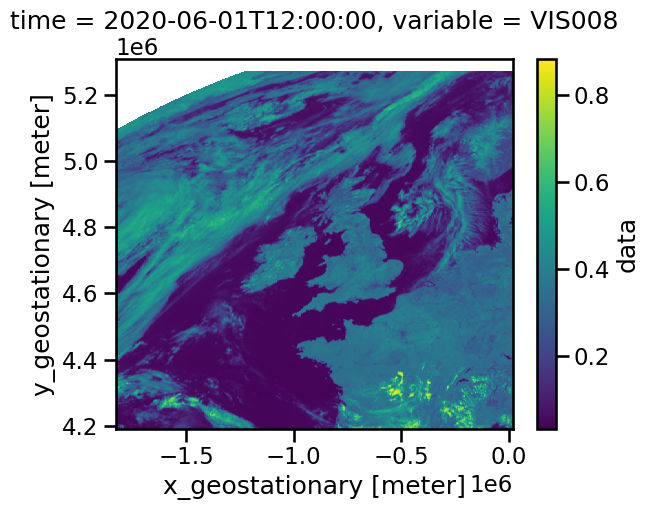

In [9]:
img = ds_sat["data"].sel(time="2020-06-01 12:00", method="nearest")
img = img.sel(variable="VIS008")

print(img.time.values)
img.plot()

Selected time: 2020-06-01T12:00:00.000000000


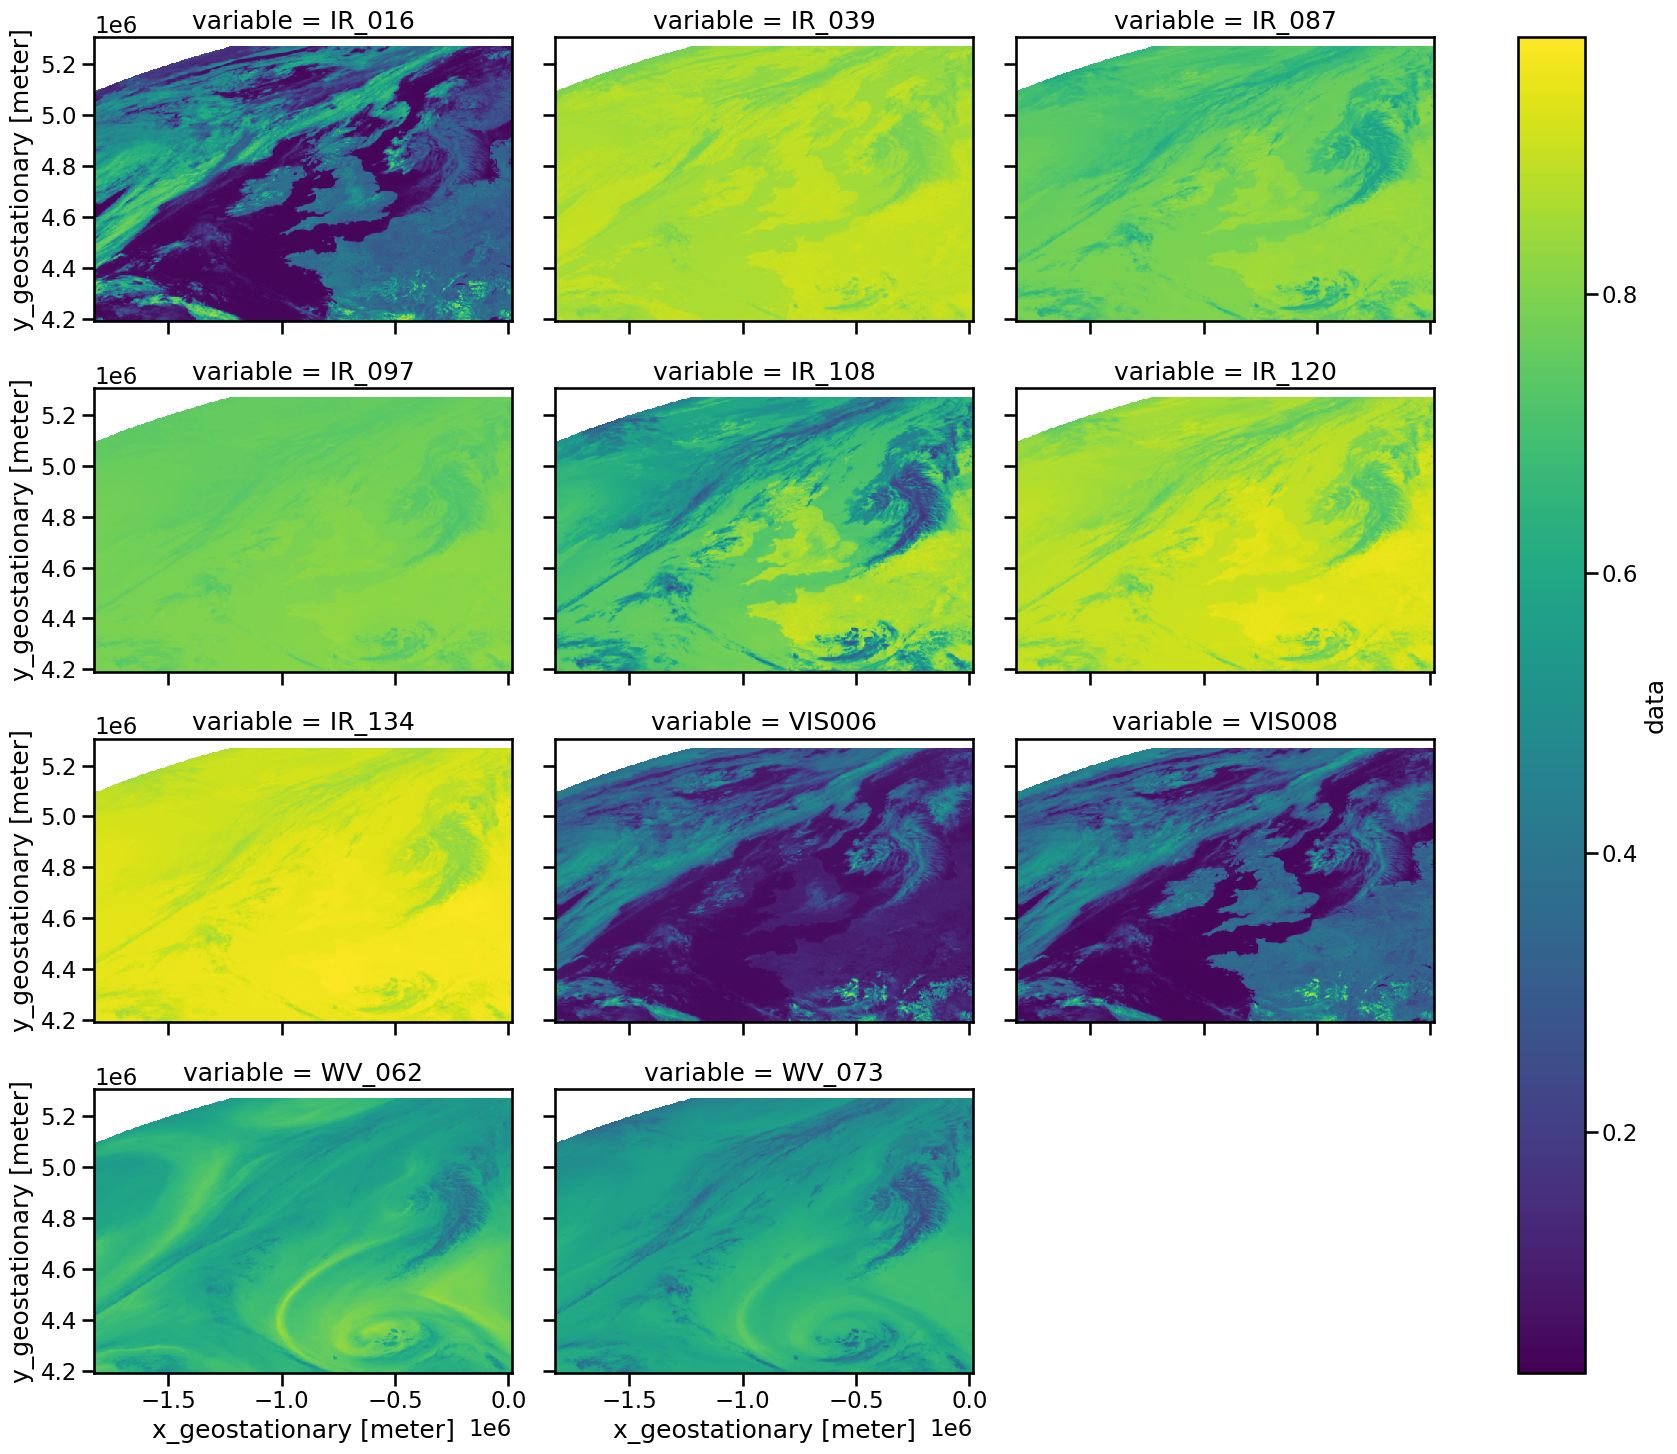

In [10]:
timestamp = "2020-06-01 12:00"

col_wrap = 3

# Select nearest available timestamp
img = ds_sat["data"].sel(time=timestamp, method="nearest")

# Calculate number of variables/channels
num_vars = img.sizes["variable"]
num_rows = (num_vars + col_wrap - 1) // col_wrap

# Scale figure size based on image aspect
fig_width = 6.14 * col_wrap
fig_height = 3.72 * num_rows

print("Selected time:", img.time.values)

img.plot(
    col="variable",
    col_wrap=col_wrap,
    figsize=(fig_width, fig_height),
)